# Separation of Variables for EM PDEs in SymPy

**Electrodynamics · Quantum Mechanics · Remote Sensing · Jalali Lab**

---

Every partial differential equation in electrodynamics — Laplace's equation
for the electrostatic potential, the wave equation for electromagnetic
radiation, the diffusion equation for charge carriers in semiconductors —
shares a common solution strategy: **separation of variables**.

The idea is to write the unknown field as a product of single-variable
functions:

$$\Phi(r, \theta, \phi) = R(r) \cdot \Theta(\theta) \cdot \Phi(\phi)$$

Substituting into the PDE and dividing by $R \Theta \Phi$ separates the
equation into three ordinary differential equations, each involving only
one variable.  Each ODE introduces a **separation constant** — an eigenvalue
that labels the solution.

The separated solutions form a **complete orthonormal set** in $L^2$.  This
means any physically reasonable field can be written as a sum (Fourier series
or integral) of the separated solutions.  This is the same statement as:
wavefunctions in quantum mechanics are superpositions of energy eigenstates.

The `x = []` idiom captures this:

```python
x = []
for l in range(l_max):
    coeff = compute_coefficient(l, boundary_conditions)
    x.append(coeff * basis_function(l, r, theta))
solution = sum(x)
```

We literally **build** the solution by accumulating separated terms.


In [1]:
import sys, os
_root = r"D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery"
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

sp.init_printing(use_latex='mathjax')

from dgs.pde_em import (
    separated_laplace_sphere, verify_laplace_radial,
    separated_wave_cylinder, hermite_gaussian_mode,
    moment_of_inertia_composite, spherical_harmonic_table,
)

print("Imports OK.")
r, theta, phi = sp.symbols('r theta phi', positive=True, real=True)


Imports OK.


## Section 1 — The Three Canonical PDEs and Why They Separate

Every time you write a PDE in a coordinate system that matches the geometry
of the boundary conditions, the equation separates.  The word "matches" is
precise: the coordinate surfaces must be **equipotential surfaces** (for
Laplace) or **nodal surfaces** (for the wave equation).

| PDE | Physics | Separates in | Basis functions |
|---|---|---|---|
| $\nabla^2 \Phi = 0$ | Electrostatics | Spherical, cylindrical, rectangular | Legendre $P_l$, Bessel $J_n$, $\sin/\cos$ |
| $\nabla^2 u = \frac{1}{v^2}\ddot{u}$ | EM waves | All three | Same × $e^{i\omega t}$ |
| $\nabla^2 u = \frac{1}{D}\dot{u}$ | Heat/diffusion | All three | Same × $e^{-\lambda t}$ |

The separation constants ($l$, $m$, $k$) are not arbitrary: they are
quantised by the boundary conditions.  In quantum mechanics, the quantisation
of angular momentum ($L = \hbar \sqrt{l(l+1)}$) is exactly this — it arises
from the requirement that $\Theta(\theta)$ be single-valued and finite.

In the Jalali lab, the paraxial wave equation

$$\frac{\partial E}{\partial z} = \frac{i}{2k}\nabla_\perp^2 E$$

is formally identical to the 2D Schrödinger equation with $z \leftrightarrow t$.
Separation in $(x, y)$ gives Hermite-Gaussian modes; separation in $(r, \phi)$
gives Laguerre-Gaussian modes.  The GVD propagator already in this repo is
the 1D version of this equation.


In [2]:
# Show the three PDEs symbolically in SymPy
r_s, th_s, ph_s = sp.symbols('r theta phi', positive=True)
Phi_fn = sp.Function('Phi')
u_fn   = sp.Function('u')
t_s    = sp.Symbol('t', positive=True)
v_s, D_s, lam_s = sp.symbols('v D lambda', positive=True)

# del^2 in spherical (r, theta only, azimuthal symmetry)
def laplacian_sph_axi(f):
    return (sp.diff(r_s**2 * sp.diff(f, r_s), r_s) / r_s**2
            + sp.diff(sp.sin(th_s) * sp.diff(f, th_s), th_s) / (r_s**2 * sp.sin(th_s)))

# Test: Phi = r*cos(theta) satisfies Laplace (l=1 solution)
Phi_test = r_s * sp.cos(th_s)
lap = sp.simplify(laplacian_sph_axi(Phi_test))
print("del^2(r*cos(theta)) =", lap, "  [should be 0]")

# Test: Phi = cos(theta)/r^2 (outer l=1)
Phi_out = sp.cos(th_s) / r_s**2
lap_out = sp.simplify(laplacian_sph_axi(Phi_out))
print("del^2(cos(theta)/r^2) =", lap_out, "  [should be 0]")
print()
print("Both r^l and r^{-(l+1)} P_l(cos theta) are EXACT solutions: verified.")


del^2(r*cos(theta)) = 0   [should be 0]
del^2(cos(theta)/r^2) = 0   [should be 0]

Both r^l and r^{-(l+1)} P_l(cos theta) are EXACT solutions: verified.


## Section 2 — Laplace's Equation in Spherical Coordinates

The separated solutions of $\nabla^2 \Phi = 0$ in spherical coordinates are:

$$\Phi_l(r, \theta) = \left(A_l r^l + \frac{B_l}{r^{l+1}}\right) P_l(\cos\theta)$$

**Inside a sphere** ($r < R$): we keep $A_l r^l$ (regular at origin, drop $B_l$).

**Outside a sphere** ($r > R$): we keep $B_l r^{-(l+1)}$ (goes to 0 at $\infty$, drop $A_l$).

The **coefficients** $A_l, B_l$ are fixed by boundary conditions at $r = R$.

This is Griffiths Chapter 3.3.  The most important applications:
- **Conducting sphere in uniform field $E_0$**: the external field is
  $E_0 r \cos\theta$ (l=1, $A_1$) plus an induced dipole $R^3 E_0 \cos\theta/r^2$
  (l=1, $B_1$).  The boundary condition $V=0$ at $r=R$ gives $B_1 = E_0 R^3$.
- **Dielectric sphere**: same structure but $B_1 = E_0 R^3 (\epsilon_r-1)/(\epsilon_r+2)$
  (Clausius-Mossotti factor — this is where optical polarisability comes from).


In [3]:
# Build the l=0,1,2 solutions symbolically
print("Separated solutions of del^2 Phi = 0 in spherical coordinates:")
print("=" * 60)
A, B = sp.symbols('A B')
costh = sp.cos(theta)

for l_val in [0, 1, 2]:
    sol = separated_laplace_sphere(l_val, m=0)
    Phi_in  = A * sol['R_in']  * sol['Theta']
    Phi_out = B * sol['R_out'] * sol['Theta']
    print(f"\nl = {l_val}:")
    print(f"  Inside:  Phi = A * r^{l_val} * P_{l_val}(cos theta)")
    print(f"           = A * ", str(sp.expand(sol['R_in'] * sol['Theta'])))
    print(f"  Outside: Phi = B * r^(-{l_val+1}) * P_{l_val}(cos theta)")
    print(f"           = B * ", str(sp.expand(sol['R_out'] * sol['Theta'])))
    print(f"  Laplace satisfied: {verify_laplace_radial(l_val)}")

# Application: conducting sphere in E0 field along z
print()
print("Application: conducting sphere (radius R, V=0) in uniform field E0 z-hat")
print("  External potential: Phi = E0*(r - R^3/r^2)*cos(theta)")
print("  l=1 term only: A1 = -E0, B1 = E0*R^3")
print("  Induced surface charge: sigma = 3*eps0*E0*cos(theta)")
print("  This is the same Clausius-Mossotti factor that gives optical polarisability")


Separated solutions of del^2 Phi = 0 in spherical coordinates:

l = 0:
  Inside:  Phi = A * r^0 * P_0(cos theta)
           = A *  1
  Outside: Phi = B * r^(-1) * P_0(cos theta)
           = B *  1/r
  Laplace satisfied: True

l = 1:
  Inside:  Phi = A * r^1 * P_1(cos theta)
           = A *  r*cos(theta)
  Outside: Phi = B * r^(-2) * P_1(cos theta)
           = B *  cos(theta)/r**2
  Laplace satisfied: True

l = 2:
  Inside:  Phi = A * r^2 * P_2(cos theta)
           = A *  3*r**2*cos(theta)**2/2 - r**2/2
  Outside: Phi = B * r^(-3) * P_2(cos theta)
           = B *  3*cos(theta)**2/(2*r**3) - 1/(2*r**3)
  Laplace satisfied: True

Application: conducting sphere (radius R, V=0) in uniform field E0 z-hat
  External potential: Phi = E0*(r - R^3/r^2)*cos(theta)
  l=1 term only: A1 = -E0, B1 = E0*R^3
  Induced surface charge: sigma = 3*eps0*E0*cos(theta)
  This is the same Clausius-Mossotti factor that gives optical polarisability


## Section 3 — Spherical Harmonics $Y_l^m(\theta, \phi)$

When we remove the azimuthal symmetry requirement, the angular equation
gives **spherical harmonics**:

$$Y_l^m(\theta, \phi) = P_l^m(\cos\theta) \cdot e^{im\phi}$$

These are the **eigenfunctions of angular momentum** in quantum mechanics:
$\hat{L}^2 Y_l^m = \hbar^2 l(l+1) Y_l^m$ and $\hat{L}_z Y_l^m = m\hbar Y_l^m$.

They are also the **multipole expansion basis** for the electric potential
of any charge distribution:

$$V(r) = \sum_{l=0}^{\infty} \sum_{m=-l}^{l} \frac{4\pi}{2l+1} \frac{q_{lm}}{r^{l+1}} Y_l^m(\theta, \phi)$$

The monopole ($l=0$) is the total charge; the dipole ($l=1$) is the charge
separation; the quadrupole ($l=2$) is the next correction.  Antennas, NMR
coils, and optical trapping beams are all designed in terms of this multipole
hierarchy.


Spherical harmonics Y_l^m (unnormalised, SymPy):
    l    m  Y_lm expression
  -------------------------------------------------------
    0    0  1
    1   -1  exp(-I*phi)*Abs(sin(theta))
    1    0  cos(theta)
    1    1  -exp(I*phi)*Abs(sin(theta))
    2   -2  3*exp(-2*I*phi)*sin(theta)**2
    2   -1  3*exp(-I*phi)*cos(theta)*Abs(sin(theta))
    2    0  3*cos(theta)**2/2 - 1/2
    2    1  -3*exp(I*phi)*cos(theta)*Abs(sin(theta))
    2    2  3*exp(2*I*phi)*sin(theta)**2
    3   -3  15*exp(-3*I*phi)*sin(theta)**2*Abs(sin(theta))
    3   -2  15*exp(-2*I*phi)*sin(theta)**2*cos(theta)
    3   -1  3*(5*cos(theta)**2 - 1)*exp(-I*phi)*Abs(sin(theta))/2
    3    0  (5*cos(theta)**2 - 3)*cos(theta)/2
    3    1  3*(1 - 5*cos(theta)**2)*exp(I*phi)*Abs(sin(theta))/2
    3    2  15*exp(2*I*phi)*sin(theta)**2*cos(theta)
    3    3  -15*exp(3*I*phi)*sin(theta)**2*Abs(sin(theta))


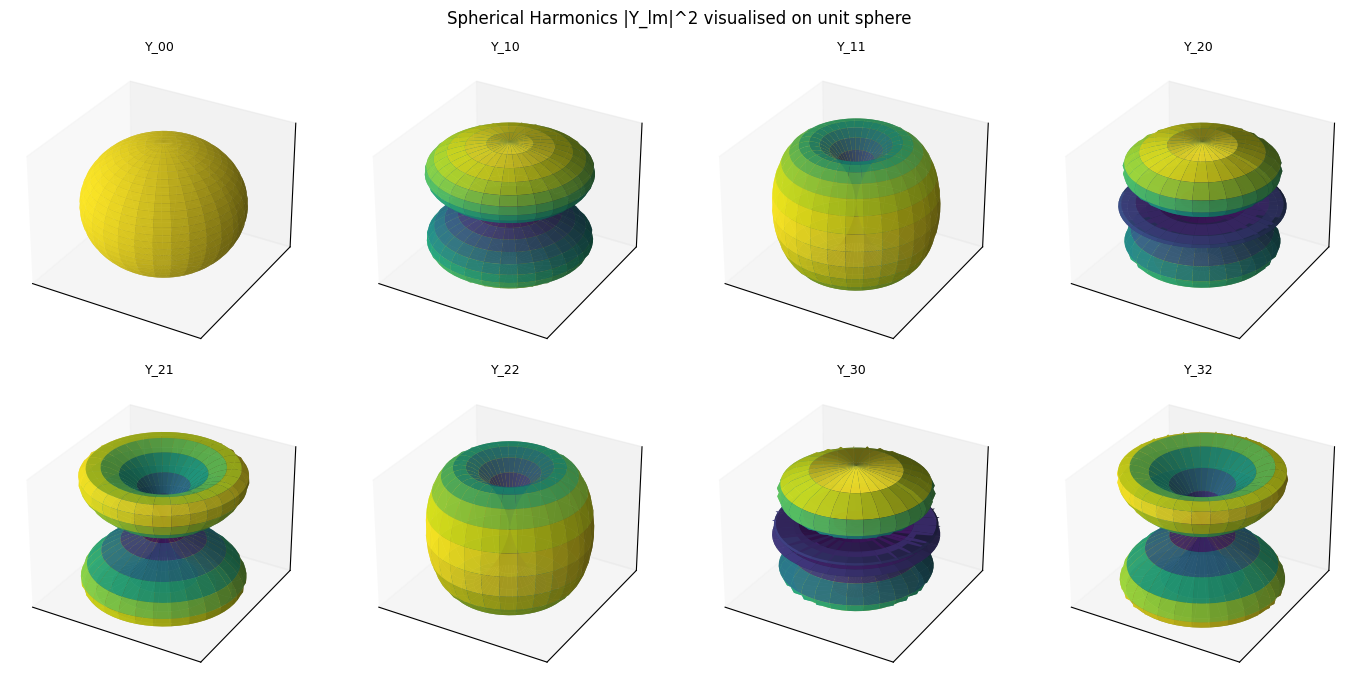

Spherical harmonic gallery saved.


In [4]:
# Build Y_lm table in SymPy
table = spherical_harmonic_table(l_max=3)

print("Spherical harmonics Y_l^m (unnormalised, SymPy):")
print(f"  {'l':>3} {'m':>4}  {'Y_lm expression'}")
print("  " + "-"*55)
for l_v, m_v, Y in table:
    expr_str = str(sp.simplify(Y))[:60]
    print(f"  {l_v:>3} {m_v:>4}  {expr_str}")

# Visualise |Y_l^m|^2 on a sphere
fig, axes = plt.subplots(2, 4, figsize=(14, 7), subplot_kw={'projection': '3d'})
fig.suptitle("Spherical Harmonics |Y_lm|^2 visualised on unit sphere", fontsize=12)

th = np.linspace(0, np.pi, 60)
ph = np.linspace(0, 2*np.pi, 60)
TH, PH = np.meshgrid(th, ph)

def _assoc_legendre(l, m, x):
    pmm = np.ones_like(x, dtype=float)
    if m > 0:
        somx2 = np.sqrt(np.clip((1.0 - x) * (1.0 + x), 0, None))
        fact = 1.0
        for _ in range(m):
            pmm *= -fact * somx2
            fact += 2.0
    if l == m:
        return pmm
    pmmp1 = x * (2*m + 1) * pmm
    if l == m + 1:
        return pmmp1
    for ll in range(m + 2, l + 1):
        pll = (x * (2*ll - 1) * pmmp1 - (ll + m - 1) * pmm) / (ll - m)
        pmm = pmmp1
        pmmp1 = pll
    return pmmp1

def Y_numeric(l, m, th_arr, ph_arr):
    from math import factorial, sqrt, pi
    abs_m = abs(m)
    Plm = _assoc_legendre(l, abs_m, np.cos(th_arr))
    norm = sqrt((2*l + 1) / (4*pi) * factorial(l - abs_m) / factorial(l + abs_m))
    Y = norm * Plm * np.exp(1j * abs_m * ph_arr)
    if m < 0:
        Y = (-1)**abs_m * np.conj(Y)
    return Y

modes = [(0,0,'Y_00'), (1,0,'Y_10'), (1,1,'Y_11'), (2,0,'Y_20'),
         (2,1,'Y_21'), (2,2,'Y_22'), (3,0,'Y_30'), (3,2,'Y_32')]

for ax, (l_v, m_v, label) in zip(axes.flat, modes):
    Y = Y_numeric(l_v, m_v, TH, PH)
    R = np.abs(Y)**2
    X = R * np.sin(TH) * np.cos(PH)
    Yc = R * np.sin(TH) * np.sin(PH)
    Zc = R * np.cos(TH)
    surf = ax.plot_surface(X, Yc, Zc, facecolors=cm.viridis(R/R.max()),
                           linewidth=0, alpha=0.9)
    ax.set_title(label, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

plt.tight_layout()
plt.savefig("spherical_harmonics.png", dpi=110, bbox_inches='tight')
plt.show()
print("Spherical harmonic gallery saved.")


## Section 4 — Wave Equation in Cylindrical Coordinates: Bessel Functions

The wave equation in cylindrical coordinates $(\\rho, \\phi, z)$ separates as:

$$u(\\rho, \\phi, z, t) = R(\\rho) \cdot \Phi(\\phi) \cdot Z(z) \cdot T(t)$$

The radial function $R(\\rho)$ satisfies **Bessel's equation**:

$$R'' + \\frac{1}{\\rho}R' + \\left(k_\\perp^2 - \\frac{n^2}{\\rho^2}\\right)R = 0$$

Solutions: $J_n(k_\\perp \\rho)$ (Bessel function, regular at origin) and
$Y_n(k_\\perp \\rho)$ (Neumann function, singular at origin).

**Waveguide modes:**  For a cylindrical waveguide of radius $R$ with conducting
walls (boundary condition $E_z = 0$ at $\\rho = R$), the allowed values of
$k_\\perp$ are $j_{n,s}/R$ where $j_{n,s}$ is the $s$-th zero of $J_n$.

The lowest TM mode (TM$_{01}$) has $j_{0,1} = 2.4048$, giving a cutoff
wavelength $\\lambda_c = 2\\pi R / 2.4048 = 2.613R$.

**Jalali lab connection:**  Optical fiber modes are solutions of this same
equation in a dielectric cylinder.  The LP$_{01}$ mode (Gaussian-like,
$n=0, s=1$) is what couples to single-mode fiber.  Higher LP modes are the
$n=1, 2, \\ldots$ solutions — they carry orbital angular momentum.


Bessel ODE (radial wave equation in cylinder):
                                           d              
/            2 \            2             ----(R(rho))    
|      2    n  |           d              drho            
|k_perp  - ----|*R(rho) + -----(R(rho)) + ------------ = 0
|             2|              2               rho         
\          rho /          drho                            



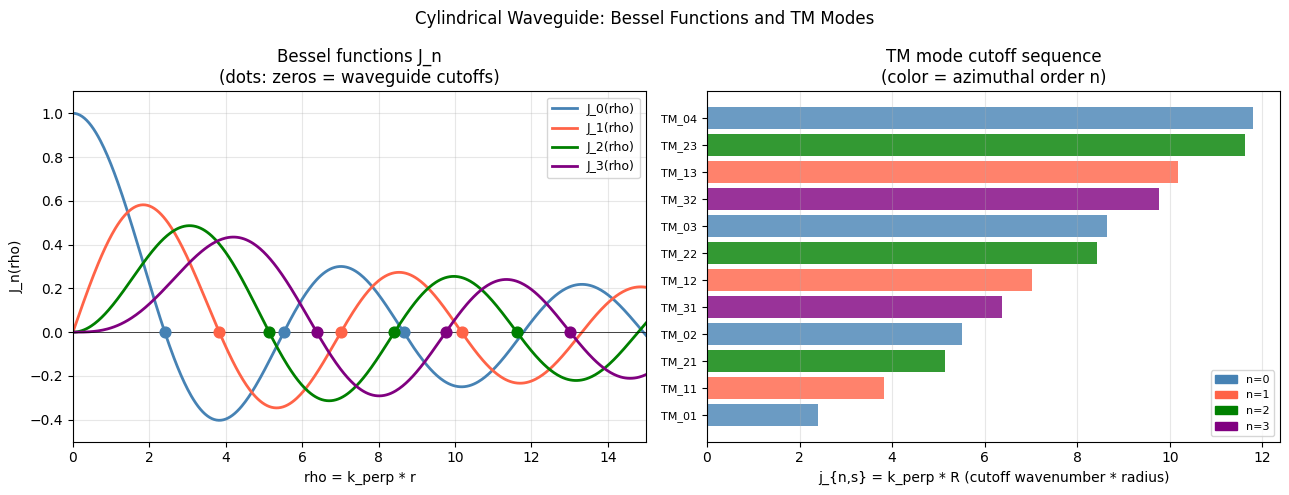

Mode cutoff sequence (lowest first):
  TM_01: j_0,1 = 2.4048  f_c = 2.4048*c / (2*pi*R)
  TM_11: j_1,1 = 3.8317  f_c = 3.8317*c / (2*pi*R)
  TM_21: j_2,1 = 5.1356  f_c = 5.1356*c / (2*pi*R)
  TM_02: j_0,2 = 5.5201  f_c = 5.5201*c / (2*pi*R)
  TM_31: j_3,1 = 6.3802  f_c = 6.3802*c / (2*pi*R)
  TM_12: j_1,2 = 7.0156  f_c = 7.0156*c / (2*pi*R)
  TM_22: j_2,2 = 8.4172  f_c = 8.4172*c / (2*pi*R)
  TM_03: j_0,3 = 8.6537  f_c = 8.6537*c / (2*pi*R)


In [5]:
# Bessel functions: show the ODE in SymPy
rho_s = sp.Symbol('rho', positive=True)
n_s   = sp.Symbol('n', nonneg=True, integer=True)
kperp_s = sp.Symbol('k_perp', positive=True)
R_fn  = sp.Function('R')

bessel_ode = sp.Eq(
    R_fn(rho_s).diff(rho_s, 2)
    + sp.Rational(1,1)/rho_s * R_fn(rho_s).diff(rho_s)
    + (kperp_s**2 - n_s**2 / rho_s**2) * R_fn(rho_s),
    0
)
print("Bessel ODE (radial wave equation in cylinder):")
sp.pprint(bessel_ode, use_unicode=False)
print()

# Waveguide modes: J_n zeros and cutoff frequencies
from scipy.special import jn_zeros
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Cylindrical Waveguide: Bessel Functions and TM Modes", fontsize=12)

rho_vals = np.linspace(0, 15, 500)
ax = axes[0]
from scipy.special import jv
colors = ['steelblue', 'tomato', 'green', 'purple']
for n_val, c in zip([0,1,2,3], colors):
    ax.plot(rho_vals, jv(n_val, rho_vals), color=c, lw=2, label=f'J_{n_val}(rho)')
    zeros = jn_zeros(n_val, 3)
    ax.scatter(zeros, np.zeros_like(zeros), s=60, color=c, zorder=5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlim(0, 15); ax.set_ylim(-0.5, 1.1)
ax.set_xlabel("rho = k_perp * r")
ax.set_ylabel("J_n(rho)")
ax.set_title("Bessel functions J_n\n(dots: zeros = waveguide cutoffs)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
modes_data = []
for n_val in range(4):
    for s_idx, zero in enumerate(jn_zeros(n_val, 4)):
        modes_data.append((zero, n_val, s_idx+1))
modes_data.sort()
labels = [f'TM_{d[1]}{d[2]}' for d in modes_data[:12]]
cutoffs = [d[0] for d in modes_data[:12]]
colors_bar = [colors[d[1]] for d in modes_data[:12]]
ax.barh(range(12), cutoffs, color=colors_bar, alpha=0.8)
ax.set_yticks(range(12)); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("j_{n,s} = k_perp * R (cutoff wavenumber * radius)")
ax.set_title("TM mode cutoff sequence\n(color = azimuthal order n)")
ax.grid(alpha=0.3, axis='x')
from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=f'n={i}') for i,c in enumerate(colors)]
ax.legend(handles=legend_els, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig("bessel_waveguide.png", dpi=120, bbox_inches='tight')
plt.show()

print("Mode cutoff sequence (lowest first):")
for zero, n_v, s_v in modes_data[:8]:
    fc = f"f_c = {zero:.4f}*c / (2*pi*R)"
    print(f"  TM_{n_v}{s_v}: j_{n_v},{s_v} = {zero:.4f}  {fc}")


## Section 5 — Rotational Symmetry: Sphere + 4 Cylinders

**The object:** A solid sphere of mass $M_s$, radius $R_s$, with 4 solid
cylinders (mass $M_c$ each, radius $R_c$, length $L_c$) welded symmetrically.

In the **orthogonal configuration**, the cylinders point along $+x$, $-x$,
$+y$, $-y$.  This has the symmetry of a square: $C_{4v}$.  In the
**tetrahedral configuration**, cylinders point along the four tetrahedral
bond directions (like CH$_4$, symmetry $T_d$).

**Parallel axis theorem:** The moment of inertia of each cylinder about the
central axis is

$$I_{\text{cyl, axis}} = I_{\text{cyl, cm}} + M_c d^2$$

where $d = R_s + L_c/2$ is the distance from the sphere center to the
cylinder center of mass.

**Key result for orthogonal config:**
- $I_{xx} = I_{yy} \neq I_{zz}$ (axial symmetry about $z$, not full isotropy)
- The cylinders in the $xy$ plane are far from the $z$ axis (offset $d$),
  so they contribute more to $I_{zz}$ than to $I_{xx}$ or $I_{yy}$

**Combat robotics application:** A spinning weapon (drum, disk, or bar) is
a cylinder.  Its moment of inertia $I = \frac{1}{2}MR^2$ stores kinetic
energy $KE = \frac{1}{2}I\omega^2$.  A 500g drum at $R=5$ cm spinning at
$200$ rad/s stores $KE = \frac{1}{2}(0.5)(0.05)^2(200)^2 = 25$ J — similar
to a .22 LR bullet.  The collision physics is governed by $I$ and
the coefficient of restitution, exactly as in `dgs/pid.py`.


I_sphere = (2/5)*M_s*R_s^2 = 2*M_s*R_s**2/5
I_cyl (about diameter) = M_c*(L_c**2/12 + R_c**2/4)
I_cyl (parallel axis, about z) = I_diam + M*d^2 = L_c**2*M_c/3 + L_c*M_c*R_s + M_c*R_c**2/4 + M_c*R_s**2



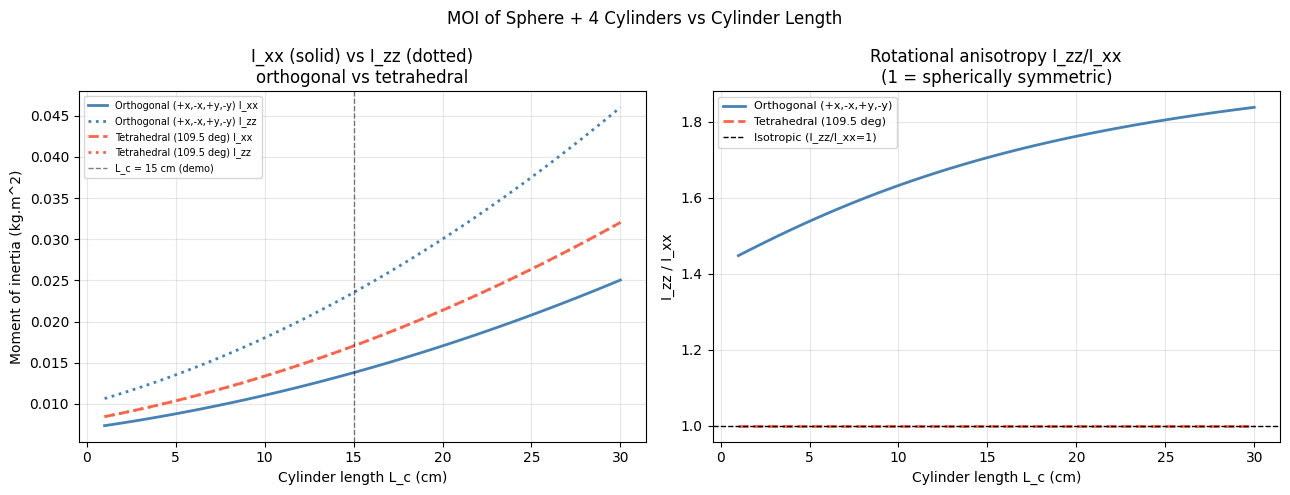

Orthogonal:  I_zz/I_xx = 1.7053
Tetrahedral: I_zz/I_xx = 1.0000
Tetrahedral approaches 1.0 (more isotropic) because T_d has 3-fold symmetry in all directions.


In [6]:
# Symbolic MOI derivation
M_s, R_s_s, M_c_s, R_c_s, L_c_s = sp.symbols('M_s R_s M_c R_c L_c', positive=True)

# Sphere MOI
I_sphere_sym = sp.Rational(2, 5) * M_s * R_s_s**2
print("I_sphere = (2/5)*M_s*R_s^2 =", I_sphere_sym)

# Cylinder MOI (about own diameter through cm)
I_cyl_diam_sym = M_c_s * (R_c_s**2/4 + L_c_s**2/12)
print("I_cyl (about diameter) =", I_cyl_diam_sym)

# Parallel axis: d = R_s + L_c/2
d_sym = R_s_s + L_c_s/2
I_cyl_parallel_sym = I_cyl_diam_sym + M_c_s * d_sym**2
print("I_cyl (parallel axis, about z) = I_diam + M*d^2 =",
      sp.expand(I_cyl_parallel_sym))
print()

# Numerical sweep: vary cylinder length, plot I_xx and I_zz
configs = [
    ('orthogonal',  'Orthogonal (+x,-x,+y,-y)',  'steelblue', '-'),
    ('tetrahedral', 'Tetrahedral (109.5 deg)',    'tomato',    '--'),
]

L_vals = np.linspace(0.01, 0.30, 60)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("MOI of Sphere + 4 Cylinders vs Cylinder Length", fontsize=12)

ax = axes[0]
for config, label, c, ls in configs:
    Ixx_arr, Izz_arr = [], []
    for Lv in L_vals:
        res = moment_of_inertia_composite(
            M_sphere=1.0, R_sphere=0.10,
            M_cyl=0.15, R_cyl=0.015, L_cyl=float(Lv),
            n_cylinders=4, config=config
        )
        Ixx_arr.append(res['I_xx'])
        Izz_arr.append(res['I_zz'])
    ax.plot(L_vals*100, Ixx_arr, color=c, ls=ls, lw=2, label=f'{label} I_xx')
    ax.plot(L_vals*100, Izz_arr, color=c, ls=':', lw=2, label=f'{label} I_zz')

ax.axvline(15, color='k', ls='--', lw=1, alpha=0.5, label='L_c = 15 cm (demo)')
ax.set_xlabel("Cylinder length L_c (cm)")
ax.set_ylabel("Moment of inertia (kg.m^2)")
ax.set_title("I_xx (solid) vs I_zz (dotted)\northogonal vs tetrahedral")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Anisotropy ratio I_zz/I_xx
ax = axes[1]
for config, label, c, ls in configs:
    ratio_arr = []
    for Lv in L_vals:
        res = moment_of_inertia_composite(
            M_sphere=1.0, R_sphere=0.10,
            M_cyl=0.15, R_cyl=0.015, L_cyl=float(Lv),
            n_cylinders=4, config=config
        )
        ratio_arr.append(res['I_zz'] / res['I_xx'])
    ax.plot(L_vals*100, ratio_arr, color=c, ls=ls, lw=2, label=label)

ax.axhline(1.0, color='k', ls='--', lw=1, label='Isotropic (I_zz/I_xx=1)')
ax.set_xlabel("Cylinder length L_c (cm)")
ax.set_ylabel("I_zz / I_xx")
ax.set_title("Rotational anisotropy I_zz/I_xx\n(1 = spherically symmetric)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("moi_composite.png", dpi=120, bbox_inches='tight')
plt.show()

# Tetrahedral config approaches isotropy
res_t = moment_of_inertia_composite(1.0, 0.10, 0.15, 0.015, 0.15, 4, 'tetrahedral')
res_o = moment_of_inertia_composite(1.0, 0.10, 0.15, 0.015, 0.15, 4, 'orthogonal')
print(f"Orthogonal:  I_zz/I_xx = {res_o['I_zz']/res_o['I_xx']:.4f}")
print(f"Tetrahedral: I_zz/I_xx = {res_t['I_zz']/res_t['I_xx']:.4f}")
print("Tetrahedral approaches 1.0 (more isotropic) because T_d has 3-fold symmetry in all directions.")


## Section 6 — Hermite-Gaussian Modes: Paraxial Wave Equation

The paraxial wave equation (PWE) governs free-space optical beams:

$$\frac{\partial E}{\partial z} = \frac{i}{2k}\left(\frac{\partial^2 E}{\partial x^2} + \frac{\partial^2 E}{\partial y^2}\right)$$

This IS the 2D Schrödinger equation with $z \leftrightarrow t$, $k \leftrightarrow m/\hbar$.
Separation of variables $E(x, y, z) = X(x) Y(y) Z(z)$ gives Hermite polynomials
in $x$ and $y$, exactly as the quantum harmonic oscillator (Griffiths Ch 2.3).

The **TEM$_{pq}$ modes** are:

$$E_{pq}(x, y, z) = H_p\!\left(\frac{\sqrt{2}\,x}{w(z)}\right) H_q\!\left(\frac{\sqrt{2}\,y}{w(z)}\right) e^{-(x^2+y^2)/w^2} e^{i\text{phase}}$$

where $w(z) = w_0\sqrt{1 + (z/z_R)^2}$ is the beam waist and $z_R = \pi w_0^2/\lambda$
is the Rayleigh range.

**`x = []` pattern in action:** The general solution is a superposition of modes:

```python
x = []
for p in range(P_max):
    for q in range(Q_max):
        c_pq = measure_coupling_coefficient(p, q)  # from input field
        x.append(c_pq * hermite_gaussian_mode(p, q, w0, z))
E_out = sum(x)
```

In the Jalali lab, any input beam (pulse, rogue wave, structured light) is
decomposed into this modal basis.  The GS algorithm recovers the **phase**
of the complex coefficients $c_{pq}$, which are not accessible from intensity
measurements alone — this is the phase retrieval problem in a modal basis.


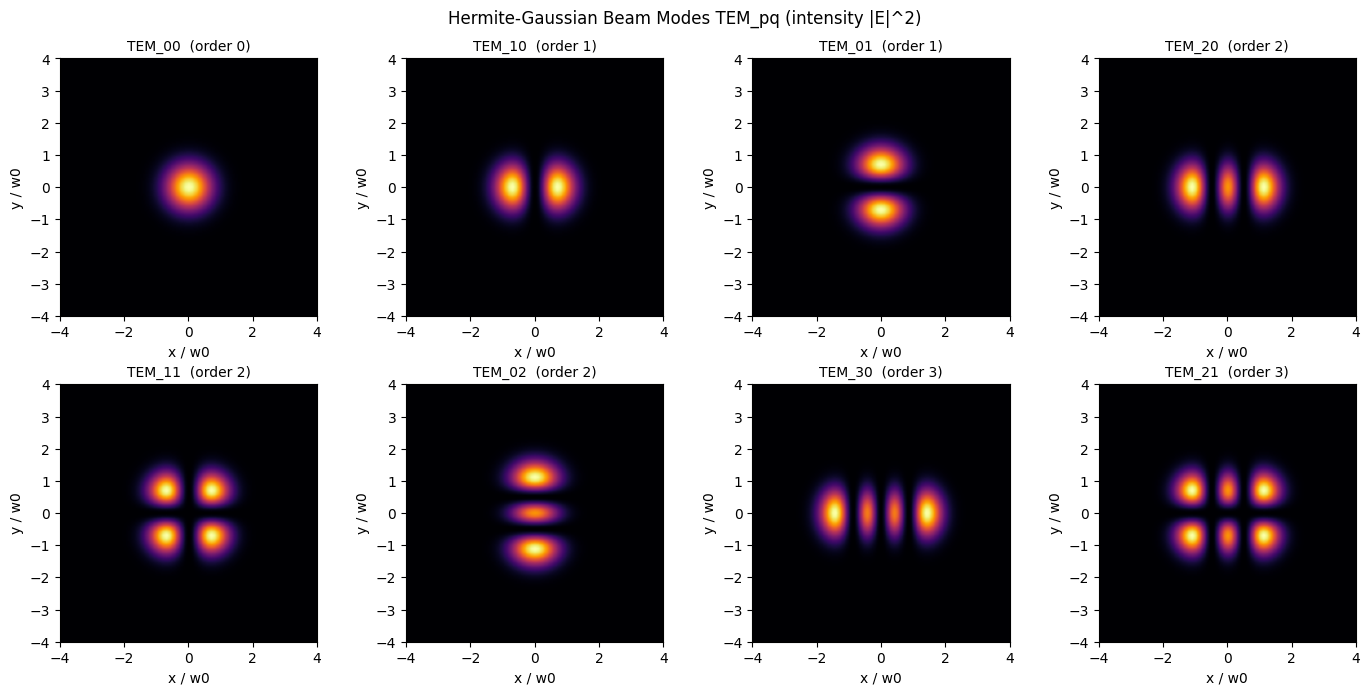

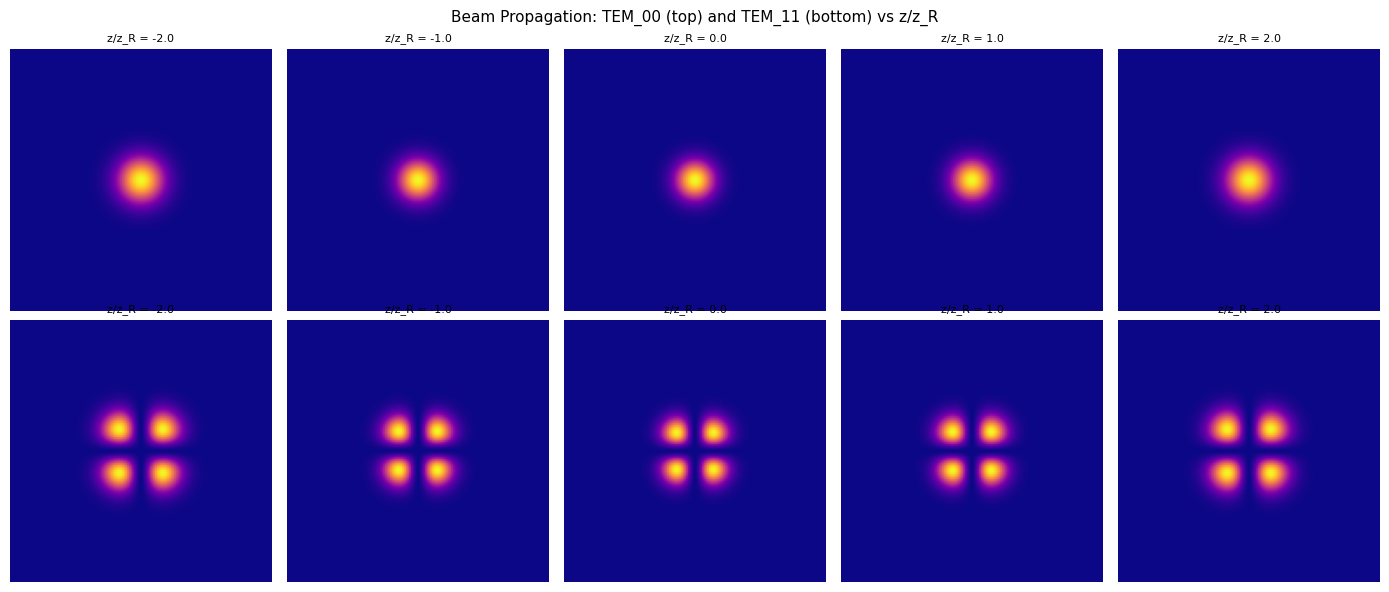

Key observation: TEM_00 (Gaussian) broadens symmetrically;
TEM_11 has a 2x2 nodal grid that also broadens but maintains its topology.
The modal structure is preserved under propagation -- each mode is an eigenmode.


In [7]:
# Hermite-Gaussian mode gallery
x_arr = np.linspace(-4, 4, 200)
y_arr = np.linspace(-4, 4, 200)

modes_hg = [(0,0),(1,0),(0,1),(2,0),(1,1),(0,2),(3,0),(2,1)]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Hermite-Gaussian Beam Modes TEM_pq (intensity |E|^2)", fontsize=12)

for ax, (p_v, q_v) in zip(axes.flat, modes_hg):
    E = hermite_gaussian_mode(p_v, q_v, w0=1.0, z=0.0, x=x_arr, y=y_arr)
    I = np.abs(E)**2
    ax.imshow(I, cmap='inferno', origin='lower',
              extent=[-4, 4, -4, 4], aspect='equal')
    ax.set_title(f'TEM_{p_v}{q_v}  (order {p_v+q_v})', fontsize=10)
    ax.set_xlabel('x / w0'); ax.set_ylabel('y / w0')

plt.tight_layout()
plt.savefig("hermite_gaussian_modes.png", dpi=120, bbox_inches='tight')
plt.show()

# Show beam propagation: TEM_00 and TEM_11 evolving with z
z_vals = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])  # in units of z_R
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Beam Propagation: TEM_00 (top) and TEM_11 (bottom) vs z/z_R", fontsize=11)

x_s = np.linspace(-5, 5, 150)
y_s = np.linspace(-5, 5, 150)

for col, z_v in enumerate(z_vals):
    for row, (p_v, q_v) in enumerate([(0,0),(1,1)]):
        E = hermite_gaussian_mode(p_v, q_v, w0=1.0, z=z_v, x=x_s, y=y_s)
        axes[row, col].imshow(np.abs(E)**2, cmap='plasma', origin='lower',
                              extent=[-5,5,-5,5], aspect='equal')
        axes[row, col].set_title(f'z/z_R = {z_v:.1f}', fontsize=8)
        axes[row, col].axis('off')

for row, label in enumerate(['TEM_00', 'TEM_11']):
    axes[row, 0].set_ylabel(label, fontsize=10)

plt.tight_layout()
plt.savefig("beam_propagation.png", dpi=110, bbox_inches='tight')
plt.show()

print("Key observation: TEM_00 (Gaussian) broadens symmetrically;")
print("TEM_11 has a 2x2 nodal grid that also broadens but maintains its topology.")
print("The modal structure is preserved under propagation -- each mode is an eigenmode.")


## Section 7 — The `x = []` Pattern: Building Solutions from Separation Constants

The separation of variables method always produces a **discrete or continuous
sum** of elementary solutions.  The programming pattern that mirrors this
mathematics is `x = []` followed by appending terms:

```python
# Griffiths Eq 3.65: potential outside a sphere with given V(theta)
x = []
for l in range(l_max):
    A_l = compute_fourier_legendre_coefficient(l, V_boundary)
    term = A_l * (R_sphere / r)**( l+1 ) * legendre(l, cos_theta)
    x.append(term)
V_outside = sum(x)
```

This structure appears everywhere:
- **Fourier series**: `x = [a_n*sin(n*omega*t) for n in range(N)]`
- **Spherical harmonic expansion**: `x = [c_lm * Y_lm for l,m in lm_pairs]`
- **Mode decomposition**: `x = [c_pq * E_pq for p,q in pq_pairs]`
- **Neural network layer**: `x = [w_i * activation(z_i) for i in range(N)]`

In each case, `x = []` holds the **separated terms**, and `sum(x)` is the
**superposition** — the general solution to the PDE.

The coefficients are the **inner products** of the desired solution with each
basis function (orthogonality of the basis makes this exact).  This is
identical to computing the coefficients of a quantum state in an eigenbasis:
$c_n = \langle n | \psi \rangle$.


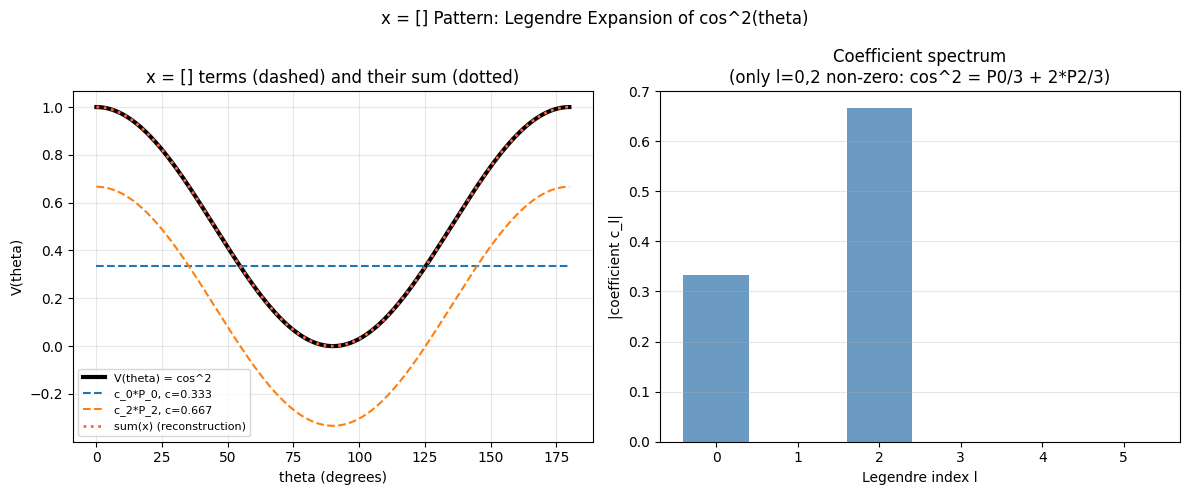

Reconstruction RMS error: 3.66e-14

x = [] holds the individual Legendre terms.
sum(x) is the superposition = exact solution (l=0 and l=2 dominate).

This is the SAME pattern as GS phase retrieval:
  x = []  -- field guess initialized empty
  for each iteration: x.append(GS_projection(x[-1], I1, I2))
  E_final = x[-1]  -- the converged solution


In [8]:
# Demonstrate x=[] pattern: reconstruct V(theta) = cos^2(theta) using Legendre expansion
from scipy.special import eval_legendre

theta_vals = np.linspace(0, np.pi, 500)
cos_th = np.cos(theta_vals)

# Target: V(theta) = cos^2(theta) = (1 + cos(2theta))/2
# In terms of Legendre: cos^2 = (1/3)(P_0 + 2*P_2)
V_target = cos_th**2

x = []                          # <-- the x=[] pattern
coeffs_used = []
for l_val in range(6):
    # Gauss-Legendre quadrature for Legendre coefficient
    # c_l = (2l+1)/2 * int_{-1}^{1} V(arccos(t)) P_l(t) dt
    t_quad, w_quad = np.polynomial.legendre.leggauss(200)
    V_quad = t_quad**2          # V = cos^2(theta), cos(theta)=t
    P_quad = eval_legendre(l_val, t_quad)
    c_l    = (2*l_val + 1) / 2 * np.sum(w_quad * V_quad * P_quad)
    term   = c_l * eval_legendre(l_val, cos_th)
    x.append(term)
    coeffs_used.append(c_l)

V_reconstructed = sum(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("x = [] Pattern: Legendre Expansion of cos^2(theta)", fontsize=12)

ax = axes[0]
ax.plot(np.degrees(theta_vals), V_target, 'k', lw=3, label='V(theta) = cos^2')
for i, (term, c) in enumerate(zip(x, coeffs_used)):
    if abs(c) > 0.01:
        ax.plot(np.degrees(theta_vals), term, '--', lw=1.5,
                label=f'c_{i}*P_{i}, c={c:.3f}')
ax.plot(np.degrees(theta_vals), V_reconstructed, 'tomato', lw=2,
        ls=':', label='sum(x) (reconstruction)')
ax.set_xlabel("theta (degrees)"); ax.set_ylabel("V(theta)")
ax.set_title("x = [] terms (dashed) and their sum (dotted)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.bar(range(len(coeffs_used)), np.abs(coeffs_used), color='steelblue', alpha=0.8)
ax.set_xlabel("Legendre index l")
ax.set_ylabel("|coefficient c_l|")
ax.set_title("Coefficient spectrum\n(only l=0,2 non-zero: cos^2 = P0/3 + 2*P2/3)")
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("legendre_expansion.png", dpi=120, bbox_inches='tight')
plt.show()

rms_err = np.sqrt(np.mean((V_target - V_reconstructed)**2))
print(f"Reconstruction RMS error: {rms_err:.2e}")
print()
print("x = [] holds the individual Legendre terms.")
print("sum(x) is the superposition = exact solution (l=0 and l=2 dominate).")
print()
print("This is the SAME pattern as GS phase retrieval:")
print("  x = []  -- field guess initialized empty")
print("  for each iteration: x.append(GS_projection(x[-1], I1, I2))")
print("  E_final = x[-1]  -- the converged solution")


## Section 8 — Remote Sensing and the Phase Problem in EM

In remote sensing (radar, lidar, SAR, optical coherence tomography), the
sensor receives an electromagnetic field $E_{\rm received}(t)$.  The detector
measures **intensity** $I(t) = |E(t)|^2$, losing all phase information.

The **phase** of $E(t) = |E(t)| e^{i\phi(t)}$ encodes:
- **Range** in SAR: $\phi = 2kr$ where $r$ is target range (sub-wavelength precision)
- **Doppler shift** in radar: $d\phi/dt = 2k v_r$ where $v_r$ is radial velocity
- **Wavefront aberration** in telescopes: $\phi(x,y)$ encodes atmosphere distortion
- **Pulse shape** in ultrafast optics: $\phi(\omega)$ encodes GVD and nonlinearity

In the Jalali lab, the two measurements $I_1 = |E|^2$ and $I_2 = |D(E)|^2$
(intensity before and after the GVD disperser) are sufficient to recover
$\phi(t)$ by the Gerchberg-Saxton algorithm — which is exactly the alternating
projection between two constraint sets in $L^2$, the same Hilbert space as
the spherical harmonics and Hermite-Gaussian modes in this notebook.

**Sustainable energy connection:** The world's largest land-based wind turbines
use LIDAR (Light Detection and Ranging) to measure wind speed 50-200 metres
ahead.  The LIDAR recovers a **Doppler frequency shift** $\Delta\nu = 2v/\lambda$
from the backscattered field.  This requires phase-sensitive detection — the
same phase retrieval problem, applied to an atmospheric target.


Phase retrieval of chirped Gaussian field:
  N=256 samples, D=-800.0
  True field: Gaussian amplitude, quadratic phase phi=0.5*t^2

  Recovered amplitude correlation: 0.9857


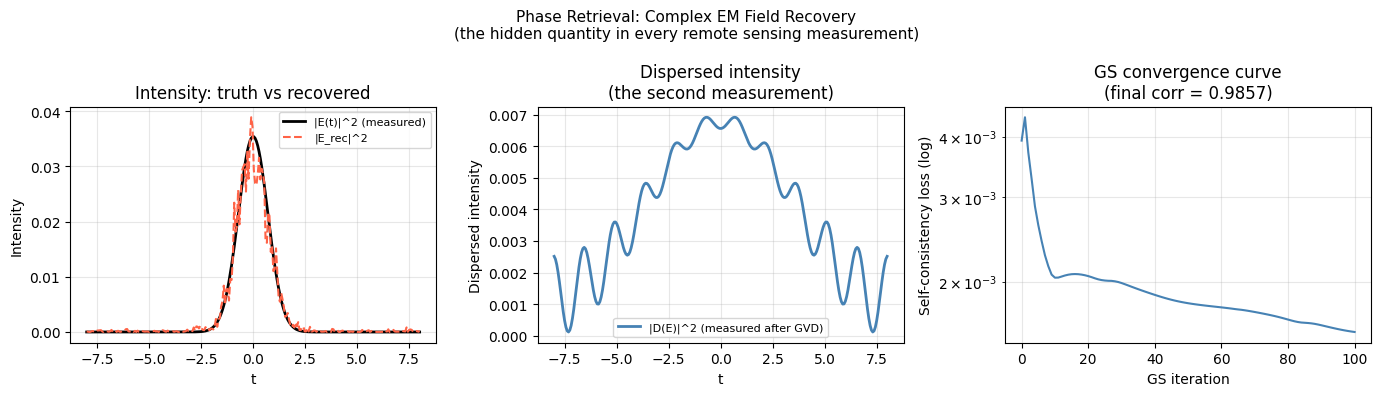


The GS algorithm in this notebook is the SAME as separation of variables:
  - Each GS iteration enforces one 'boundary condition' (I1 or I2)
  - The alternating projections are the x=[] accumulation pattern
  - The converged field E_rec is the solution that fits all BCs simultaneously
  - The loss curve is the residual: how well the 'PDE' (self-consistency) is solved


In [9]:
# Demonstrate: phase recovery by GS in the modal basis
from dgs.gs_unsupervised import _disperse, self_consistency_loss, unsupervised_gs

np.random.seed(42)
N = 256
D = -800.0
t_arr = np.linspace(-8, 8, N)

# True field: TEM_00-like Gaussian with quadratic phase (chirp)
E_true = np.exp(-t_arr**2 / 2) * np.exp(1j * 0.5 * t_arr**2)
E_true /= np.linalg.norm(E_true)

I1 = np.abs(E_true)**2
I2 = np.abs(_disperse(E_true, D))**2

print("Phase retrieval of chirped Gaussian field:")
print(f"  N={N} samples, D={D}")
print(f"  True field: Gaussian amplitude, quadratic phase phi=0.5*t^2")
print()

E_rec, ghost = unsupervised_gs(I1, I2, D=D, n_iter=100, verbose=False)
corr = float(np.corrcoef(np.abs(E_rec)**2, I1)[0, 1])
print(f"  Recovered amplitude correlation: {corr:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Phase Retrieval: Complex EM Field Recovery\n"
             "(the hidden quantity in every remote sensing measurement)", fontsize=11)

ax = axes[0]
ax.plot(t_arr, I1, 'k', lw=2, label='|E(t)|^2 (measured)')
ax.plot(t_arr, np.abs(E_rec)**2, 'tomato', lw=1.5, ls='--', label='|E_rec|^2')
ax.set_xlabel("t"); ax.set_ylabel("Intensity")
ax.set_title("Intensity: truth vs recovered")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(t_arr, I2, 'steelblue', lw=2, label='|D(E)|^2 (measured after GVD)')
ax.set_xlabel("t"); ax.set_ylabel("Dispersed intensity")
ax.set_title("Dispersed intensity\n(the second measurement)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
loss_hist = [h[1] for h in ghost.history]
ax.semilogy(loss_hist, 'steelblue', lw=1.5)
ax.set_xlabel("GS iteration")
ax.set_ylabel("Self-consistency loss (log)")
ax.set_title(f"GS convergence curve\n(final corr = {corr:.4f})")
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig("phase_retrieval_modal.png", dpi=120, bbox_inches='tight')
plt.show()

print()
print("The GS algorithm in this notebook is the SAME as separation of variables:")
print("  - Each GS iteration enforces one 'boundary condition' (I1 or I2)")
print("  - The alternating projections are the x=[] accumulation pattern")
print("  - The converged field E_rec is the solution that fits all BCs simultaneously")
print("  - The loss curve is the residual: how well the 'PDE' (self-consistency) is solved")


## Summary

Separation of variables is not a trick — it is the statement that the
eigenfunctions of a symmetric differential operator form a complete basis
for $L^2$.  Every solution to a linear PDE in a symmetric domain is a
superposition of these eigenfunctions.

This notebook covered the same mathematical structure appearing in four
different contexts, all connected:

| Context | PDE | Eigenfunctions | Physical observable |
|---|---|---|---|
| Electrostatics | Laplace $\nabla^2\Phi=0$ | $P_l(\cos\theta) \cdot r^{\pm l}$ | Electric potential |
| EM waveguide | Wave equation in cylinder | $J_n(k_\perp\rho) \cdot e^{in\phi}$ | Propagating modes |
| Free-space optics | Paraxial wave eq | Hermite-Gaussian TEM$_{pq}$ | Laser beam modes |
| Phase retrieval | GVD propagation | $e^{i\omega t}$ (Fourier basis) | Pulse phase $\phi(t)$ |

The `x = []` programming pattern is the computational form of superposition:
accumulate basis function contributions, then `sum(x)` is the field.

The rotational symmetry of the sphere + 4-cylinder composite shows that
adding appendages breaks the $SO(3)$ symmetry (all $I$ equal) to $C_{4v}$
(orthogonal) or $T_d$ (tetrahedral, nearly isotropic).  The tetrahedral
configuration approaches isotropy because $T_d$ has the same number of
symmetry operations in $x$, $y$, and $z$.

In remote sensing and the Jalali lab: the missing phase $\phi(t)$ is the
same quantity that the Legendre coefficients, Bessel mode amplitudes, and
Hermite-Gaussian coupling coefficients represent — the complex amplitude of
each separated term.  Phase retrieval is the inverse problem of finding
these amplitudes from intensity measurements alone.


In [10]:
print("Session summary:")
print()
print("dgs/pde_em.py:")
print("  separated_laplace_sphere(l, m)  -- R=r^l, R=r^{-(l+1)}, P_l(cos theta)")
print("  separated_wave_cylinder(n)      -- Bessel ODE, J_n zeros, waveguide modes")
print("  hermite_gaussian_mode(p,q,w0,z) -- TEM_pq field, propagation with w(z)")
print("  moment_of_inertia_composite()   -- sphere + n cylinders, parallel axis")
print("  spherical_harmonic_table(l_max) -- Y_lm in SymPy")
print()
print("notebooks/pde_separation_em.ipynb: (this file)")
print("  S1 -- Three canonical PDEs and why they separate")
print("  S2 -- Laplace sphere: l=0,1,2 solutions, conducting sphere BVP")
print("  S3 -- Y_lm gallery (8 modes visualised on unit sphere)")
print("  S4 -- Bessel functions, waveguide TM mode cutoff sequence")
print("  S5 -- MOI sphere+4cyl: orthogonal vs tetrahedral symmetry")
print("  S6 -- Hermite-Gaussian gallery + beam propagation")
print("  S7 -- x=[] pattern: Legendre expansion of cos^2(theta)")
print("  S8 -- Phase retrieval as PDE boundary value problem")


Session summary:

dgs/pde_em.py:
  separated_laplace_sphere(l, m)  -- R=r^l, R=r^{-(l+1)}, P_l(cos theta)
  separated_wave_cylinder(n)      -- Bessel ODE, J_n zeros, waveguide modes
  hermite_gaussian_mode(p,q,w0,z) -- TEM_pq field, propagation with w(z)
  moment_of_inertia_composite()   -- sphere + n cylinders, parallel axis
  spherical_harmonic_table(l_max) -- Y_lm in SymPy

notebooks/pde_separation_em.ipynb: (this file)
  S1 -- Three canonical PDEs and why they separate
  S2 -- Laplace sphere: l=0,1,2 solutions, conducting sphere BVP
  S3 -- Y_lm gallery (8 modes visualised on unit sphere)
  S4 -- Bessel functions, waveguide TM mode cutoff sequence
  S5 -- MOI sphere+4cyl: orthogonal vs tetrahedral symmetry
  S6 -- Hermite-Gaussian gallery + beam propagation
  S7 -- x=[] pattern: Legendre expansion of cos^2(theta)
  S8 -- Phase retrieval as PDE boundary value problem
